In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import re

pio.templates["compact"] = pio.templates["plotly"].update({
    "layout": {"autosize": False, "width": 500, "height": 400}
})
pio.templates.default = "compact"

In [2]:
df = pd.read_csv("07_flats_EDA.csv")

In [3]:
df.shape

(2911, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2911 entries, 0 to 2910
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price_cr                2904 non-null   float64
 1   area_sqm                2911 non-null   float64
 2   bhk                     2911 non-null   int64  
 3   bathroom                2911 non-null   int64  
 4   balcony                 2911 non-null   int64  
 5   addl_room               2911 non-null   int64  
 6   sector                  2911 non-null   int64  
 7   landmark_count          2911 non-null   int64  
 8   has_hospital_or_clinic  2911 non-null   int64  
 9   has_police_stn          2911 non-null   int64  
 10  has_fire_stn            2911 non-null   int64  
 11  has_mall                2911 non-null   int64  
 12  has_market              2911 non-null   int64  
 13  has_park                2911 non-null   int64  
 14  has_bank_or_atm         2911 non-null   

In [5]:
df.head(2)

,price_cr,area_sqm,bhk,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,...,has_temple_or_church,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city
0,0.45,83.61,2,2,1,0,7,50,34,0,...,1,0,0,0,1,carpet,mid,new,maa bhagwati residency,gurgaon
1,0.50,60.39,2,2,1,0,3,48,4,0,...,2,0,0,0,0,carpet,low,old,apna enclave,gurgaon


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price_cr,2904.0,NaN,NaN,NaN,1.729607,1.406123,0.16,0.9,1.4,2.09,15.0
area_sqm,2911.0,NaN,NaN,NaN,168.088822,89.376428,6.69,120.77,161.19,199.74,1683.59
bhk,2911.0,NaN,NaN,NaN,2.810374,0.791129,1.0,2.0,3.0,3.0,6.0
bathroom,2911.0,NaN,NaN,NaN,2.967365,1.045018,1.0,2.0,3.0,4.0,7.0
balcony,2911.0,NaN,NaN,NaN,2.460666,0.789372,0.0,2.0,3.0,3.0,3.0
addl_room,2911.0,NaN,NaN,NaN,0.576434,0.494208,0.0,0.0,1.0,1.0,1.0
sector,2911.0,NaN,NaN,NaN,70.537616,28.826174,1.0,51.0,78.0,91.0,142.0
landmark_count,2911.0,NaN,NaN,NaN,14.299897,11.384368,3.0,9.0,10.0,14.0,50.0
has_hospital_or_clinic,2911.0,NaN,NaN,NaN,2.272415,4.712307,0.0,1.0,1.0,1.0,42.0
has_police_stn,2911.0,NaN,NaN,NaN,0.014772,0.120658,0.0,0.0,0.0,0.0,1.0


In [7]:
df.columns

Index(['price_cr', 'area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room',
       'sector', 'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city'],
      dtype='object')

In [8]:
df.isnull().sum()

price_cr                  7
area_sqm                  0
bhk                       0
bathroom                  0
balcony                   0
addl_room                 0
sector                    0
landmark_count            0
has_hospital_or_clinic    0
has_police_stn            0
has_fire_stn              0
has_mall                  0
has_market                0
has_park                  0
has_bank_or_atm           0
has_institute             0
has_airport               0
has_rly_stn               0
has_metro_stn             0
has_expy                  0
has_petrol_pump           0
has_hotel                 0
has_temple_or_church      0
has_famous_chowk          0
has_club                  0
has_stadium               0
has_restro_cafe           0
area_type                 0
floor_rise                0
age                       0
society                   0
city                      0
dtype: int64

In [9]:
df.dropna(inplace=True)

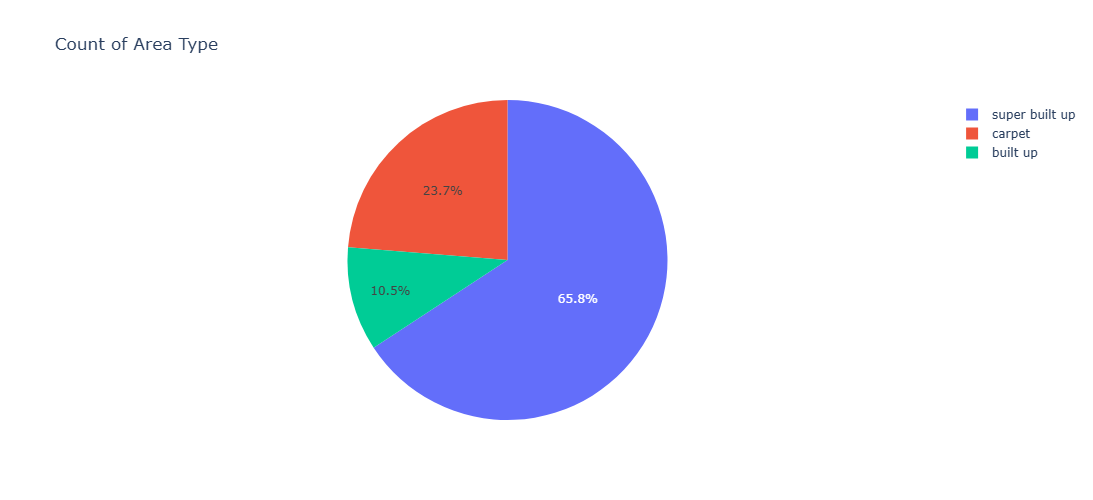

In [10]:
px.pie(df, names='area_type', title='Count of Area Type', height=500)

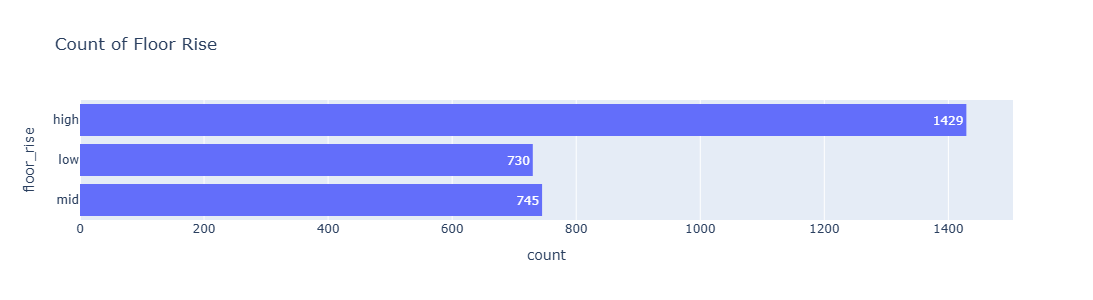

In [11]:
px.histogram(df, y='floor_rise', title='Count of Floor Rise', text_auto=True, height=300)

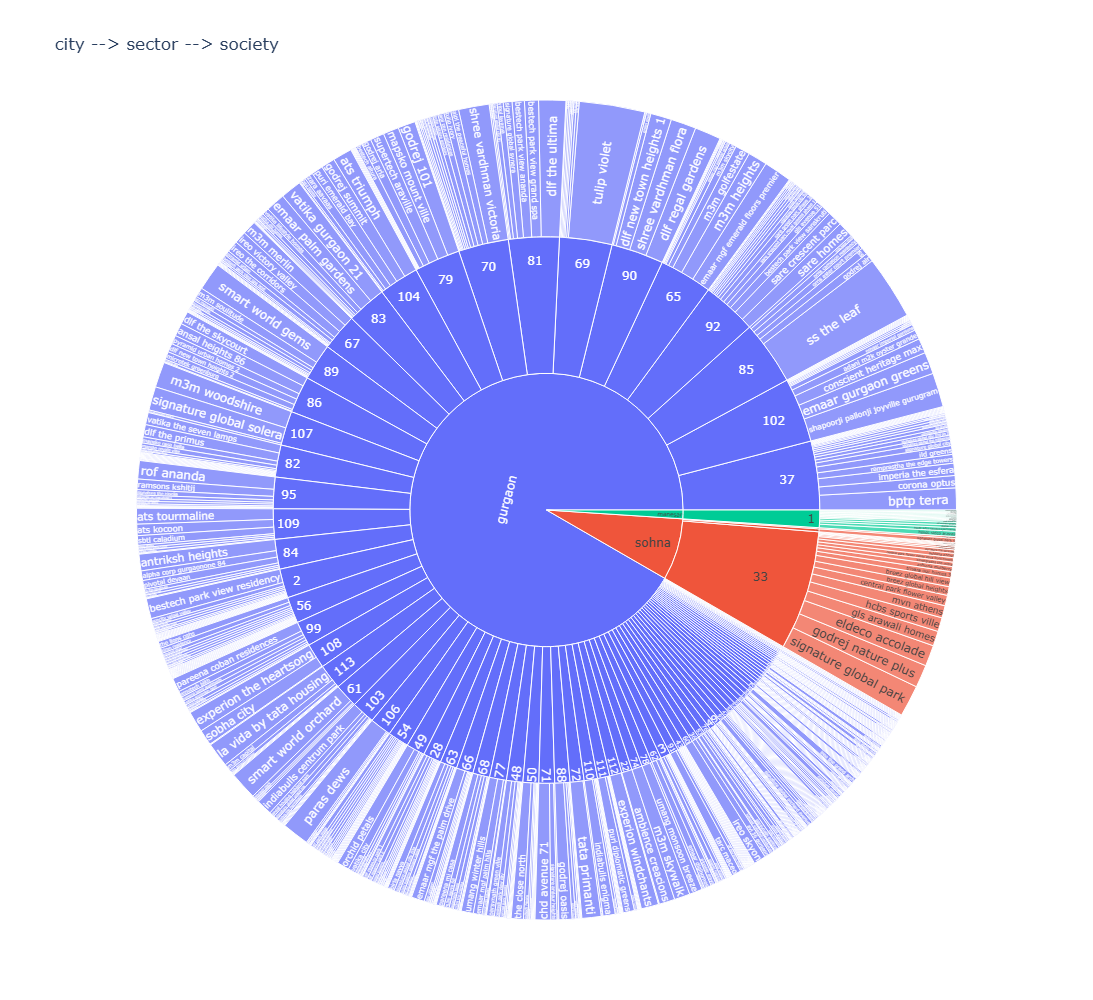

In [12]:
px.sunburst(df, path=["city", "sector", "society"], title='city --> sector --> society', color='city', height=1000, width=800)

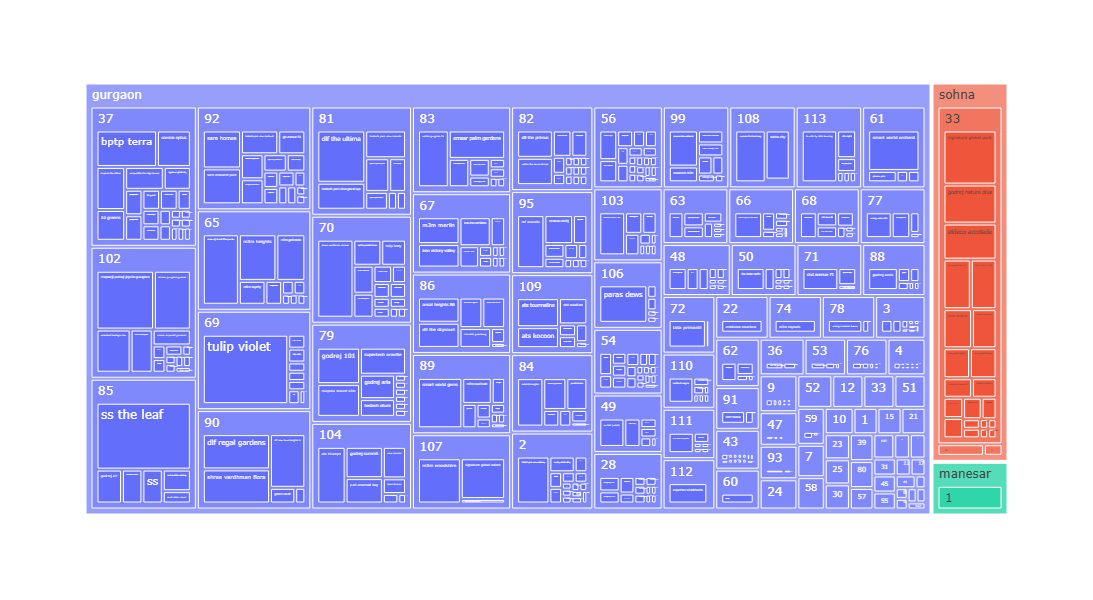

In [13]:
px.treemap(df, 
           path=["city", "sector", "society"], 
           height=600, width=1000
)

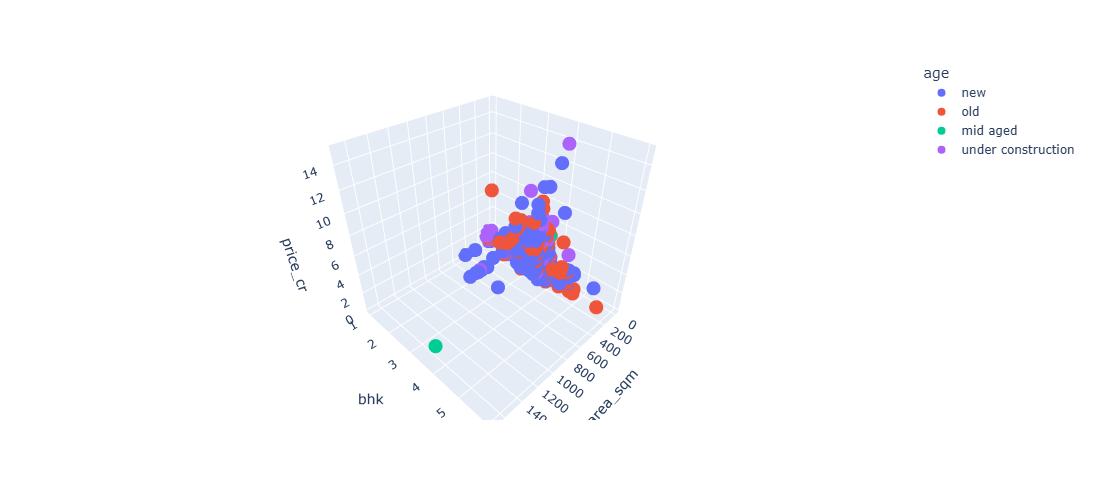

In [14]:
px.scatter_3d(df,
                x='area_sqm',
                y='bhk',
                z='price_cr',
                log_y=False,
                color='age',
                hover_name='society',
                 width=1000,
                 height=500)

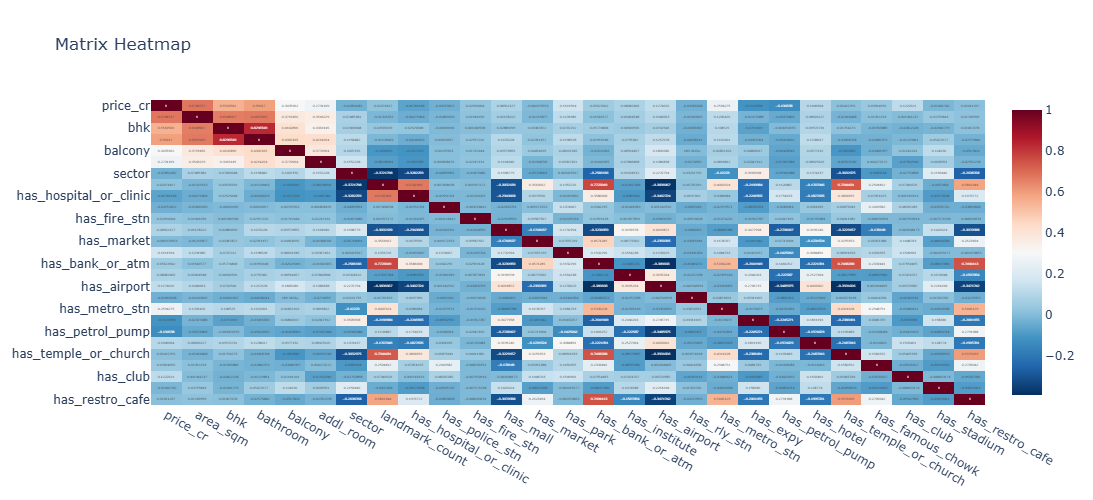

In [15]:
fig = px.imshow(df.corr(numeric_only=True),
                text_auto=True,
                color_continuous_scale="RdBu_r",
                aspect="auto",
                title="Matrix Heatmap",
               height=500,
               width=1000)
fig.show()

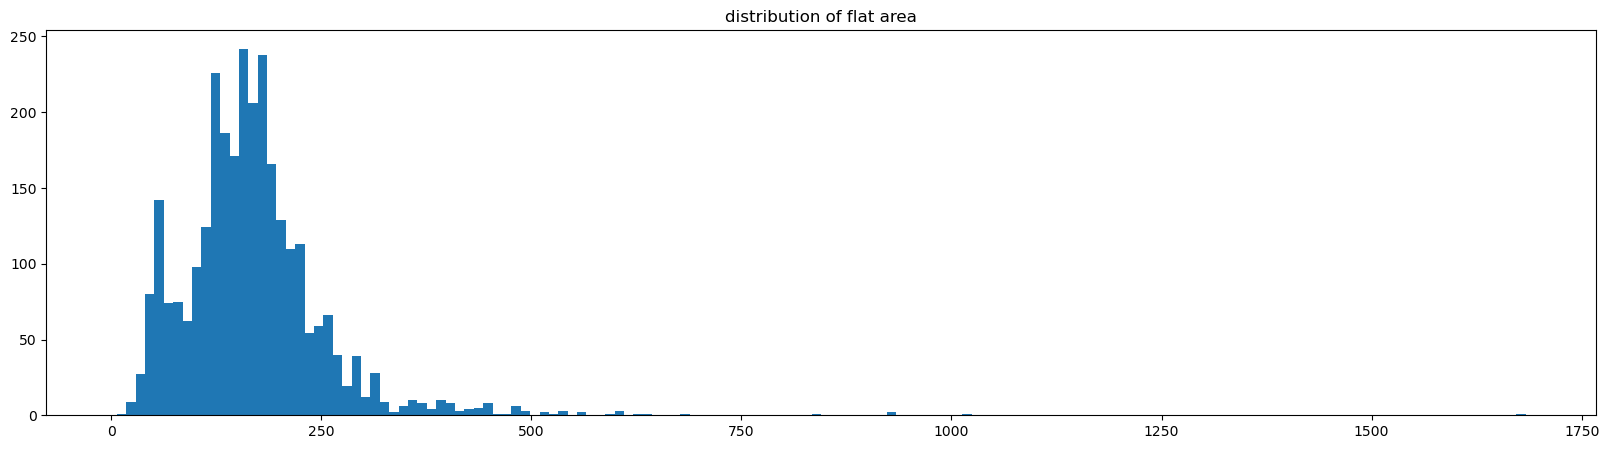

In [16]:
plt.figure(figsize=(20,5))
plt.hist(x=df['area_sqm'], bins=150, log=False)
plt.title("distribution of flat area")
plt.show()

In [17]:
df.columns

Index(['price_cr', 'area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room',
       'sector', 'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city'],
      dtype='object')

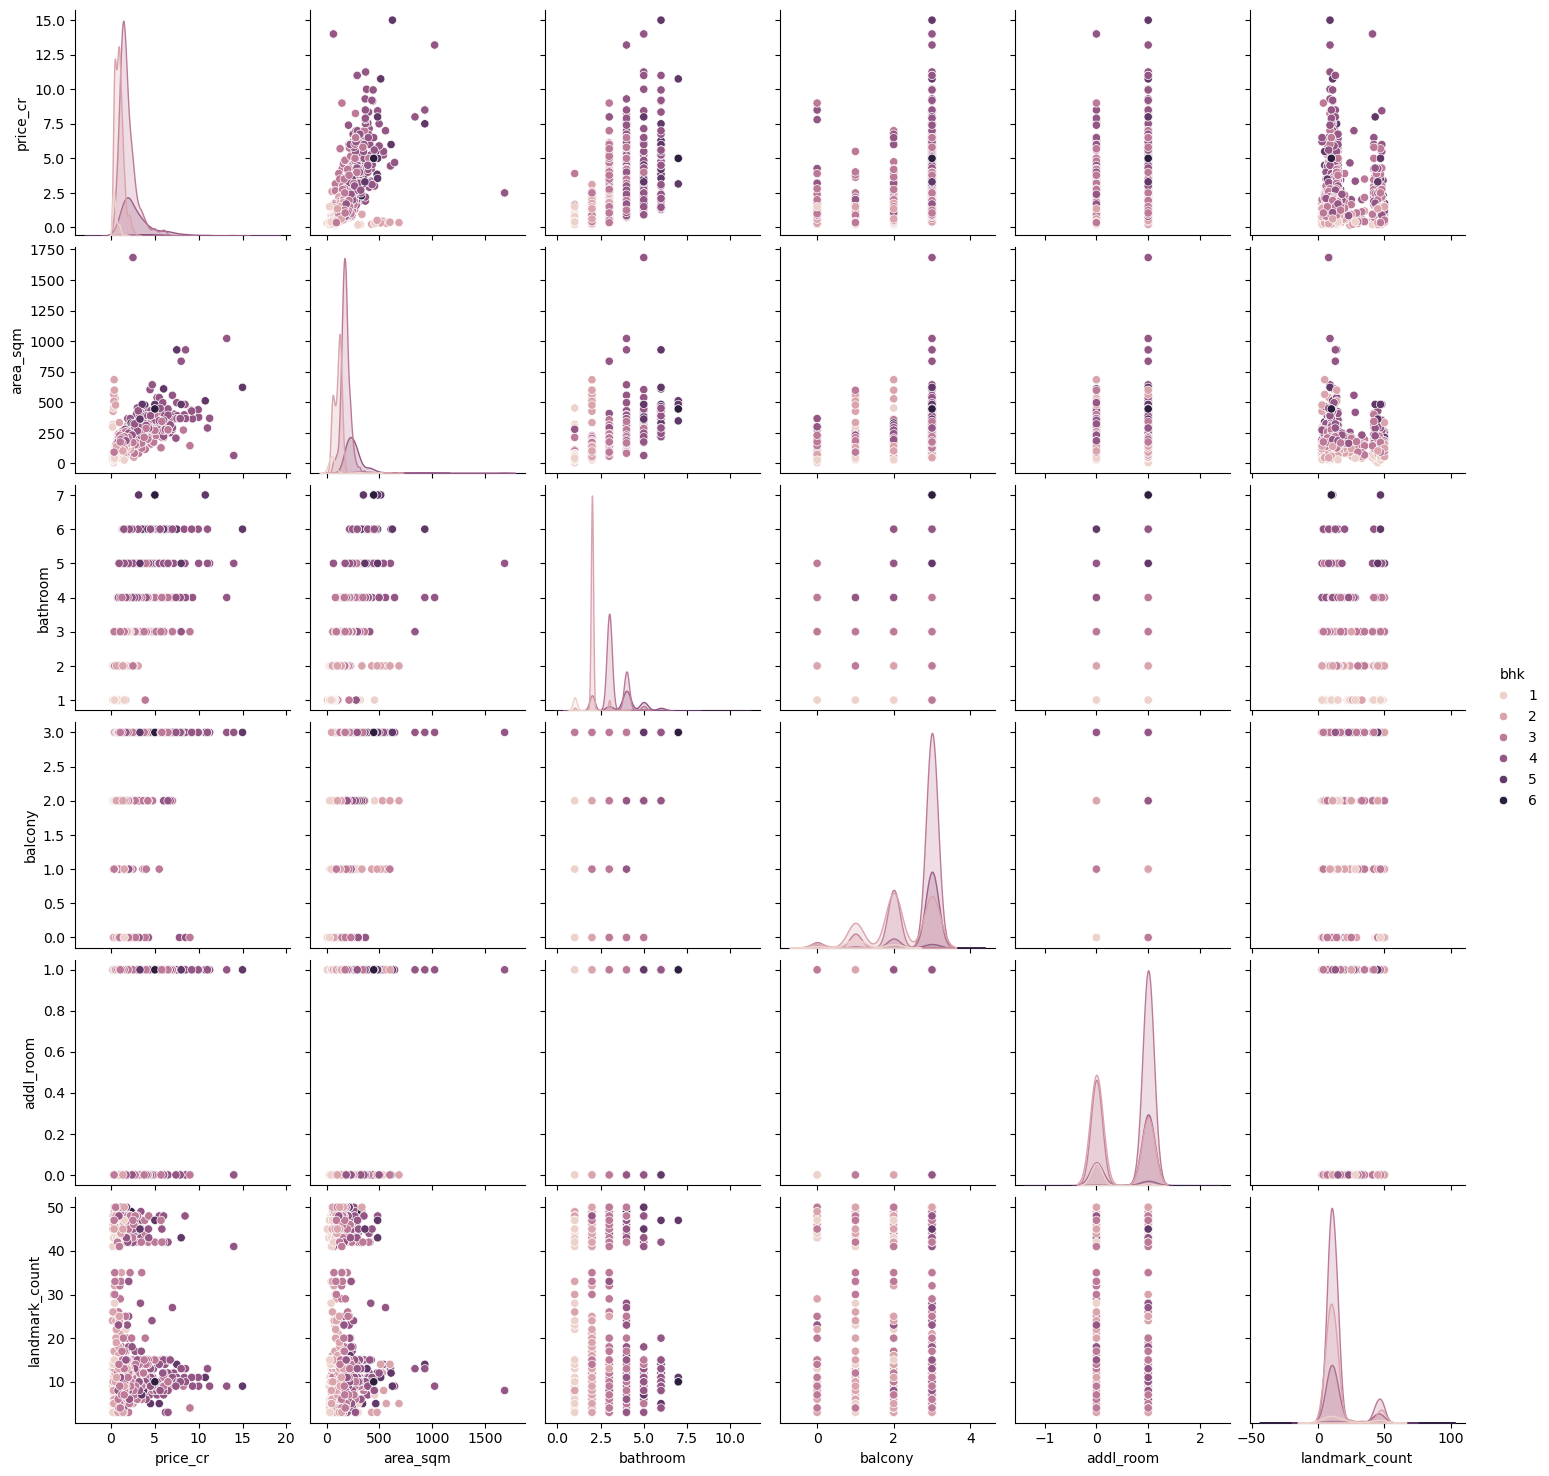

In [18]:
df1 = df[['price_cr', 'area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room','landmark_count']]
sns.pairplot(df1, hue='bhk')

In [19]:
grp_sector_wise = df.groupby(['city','sector'])[['price_cr','area_sqm','bhk','landmark_count']].mean()
grp_sector_wise = grp_sector_wise.query("city == 'gurgaon'")
grp_sector_wise

price_cr    area_sqm       bhk  landmark_count
city    sector                                                
gurgaon 1       1.262000  208.290000  3.400000       27.200000
        2       1.851400  193.087200  2.540000       14.000000
        3       0.664118   87.927059  2.176471       39.000000
        4       0.480909   81.924545  2.090909       48.181818
        5       0.260000   54.160000  1.000000       48.000000
...                  ...         ...       ...             ...
        110     2.647391  241.140000  3.608696       15.434783
        111     2.609524  203.704286  3.095238       12.666667
        112     4.023333  314.749524  3.095238        8.000000
        113     2.465814  198.723721  3.046512        9.023256
        142     3.500000  195.100000  3.000000       35.000000

[91 rows x 4 columns]

In [20]:
df_lat_long = pd.read_csv('08_latlong.csv')
df_lat_long['sector_num'] = df_lat_long['sector'].str.extract(r"(\d+)").replace(np.nan, -1).astype('int64')
df_lat_long

,sector,coordinates,sector_num
0,sector 1,"28.3663° N, 76.9456° E",1
1,sector 2,"28.5095° N, 77.0320° E",2
2,sector 3,"28.4909° N, 77.0176° E",3
3,sector 4,"28.4738° N, 77.0107° E",4
4,sector 5,"28.4794° N, 77.0176° E",5
...,...,...,...
124,sector 113,"28.5287° N, 77.0233° E",113
125,sector 114,"28.5334° N, 77.0118° E",114
126,sector 115,"28.5385° N, 77.0061° E",115
127,gwal pahari,"28.4484° N, 77.0210° E",-1


In [21]:
grp_sector_wise = grp_sector_wise.merge(df_lat_long, 'left', left_on='sector', right_on='sector_num')
grp_sector_wise['lat'] = grp_sector_wise['coordinates'].str.split(',').str[0].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise['long'] = grp_sector_wise['coordinates'].str.split(',').str[1].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise.drop(columns=['coordinates'], inplace=True)
grp_sector_wise

,price_cr,area_sqm,bhk,landmark_count,sector,sector_num,lat,long
0,1.262000,208.290000,3.400000,27.200000,sector 1,1.0,28.3663,76.9456
1,1.851400,193.087200,2.540000,14.000000,sector 2,2.0,28.5095,77.0320
2,0.664118,87.927059,2.176471,39.000000,sector 3,3.0,28.4909,77.0176
3,0.480909,81.924545,2.090909,48.181818,sector 4,4.0,28.4738,77.0107
4,0.260000,54.160000,1.000000,48.000000,sector 5,5.0,28.4794,77.0176
...,...,...,...,...,...,...,...,...
98,2.647391,241.140000,3.608696,15.434783,sector 110,110.0,28.5145,77.0197
99,2.609524,203.704286,3.095238,12.666667,sector 111,111.0,28.5238,77.0320
100,4.023333,314.749524,3.095238,8.000000,sector 112,112.0,28.5189,77.0183
101,2.465814,198.723721,3.046512,9.023256,sector 113,113.0,28.5287,77.0233


In [22]:
grp_sector_wise.dropna(inplace=True)

In [23]:
grp_sector_wise

,price_cr,area_sqm,bhk,landmark_count,sector,sector_num,lat,long
0,1.262000,208.290000,3.400000,27.200000,sector 1,1.0,28.3663,76.9456
1,1.851400,193.087200,2.540000,14.000000,sector 2,2.0,28.5095,77.0320
2,0.664118,87.927059,2.176471,39.000000,sector 3,3.0,28.4909,77.0176
3,0.480909,81.924545,2.090909,48.181818,sector 4,4.0,28.4738,77.0107
4,0.260000,54.160000,1.000000,48.000000,sector 5,5.0,28.4794,77.0176
...,...,...,...,...,...,...,...,...
97,1.765000,201.856538,3.096154,12.230769,sector 109,109.0,28.5073,77.0089
98,2.647391,241.140000,3.608696,15.434783,sector 110,110.0,28.5145,77.0197
99,2.609524,203.704286,3.095238,12.666667,sector 111,111.0,28.5238,77.0320
100,4.023333,314.749524,3.095238,8.000000,sector 112,112.0,28.5189,77.0183


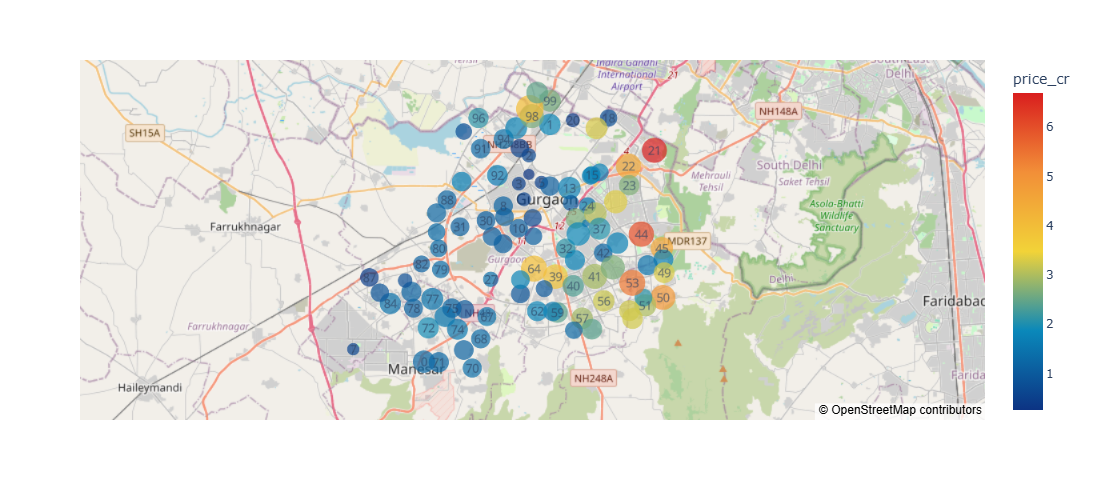

In [24]:
fig = px.scatter_mapbox(grp_sector_wise, lat="lat", lon="long", color="price_cr", size='area_sqm',
                  color_continuous_scale=px.colors.diverging.Portland, zoom=10, width=1000, height=500,
                  mapbox_style="open-street-map", text=grp_sector_wise.index.astype(str))
fig.show()

In [25]:
#sector 44 and 53 seem to be the most expensive sectors on an average.
#sector 50, 45, 22, 98, 64 and 39 seem to be moderately expensive on an average.
#others are cheap

<Axes: title={'center': 'Top 10 Societies by frequency'}, ylabel='society'>

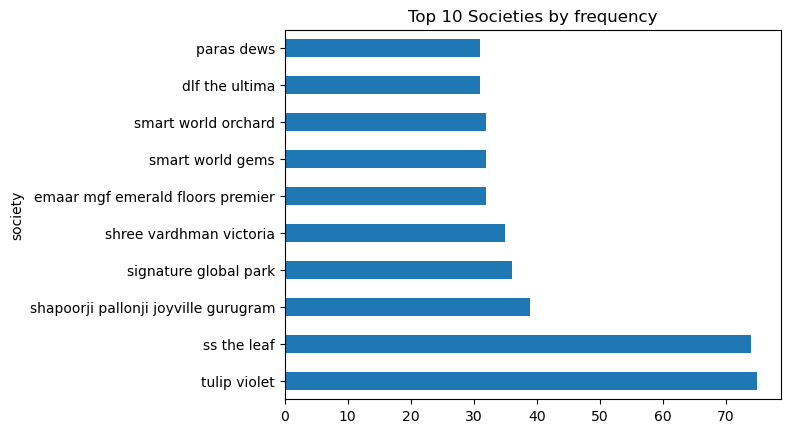

In [26]:
df['society'].value_counts().head(10).plot(kind='barh', title='Top 10 Societies by frequency')

<Axes: title={'center': 'Top 10 Sectors by frequency'}, xlabel='sector'>

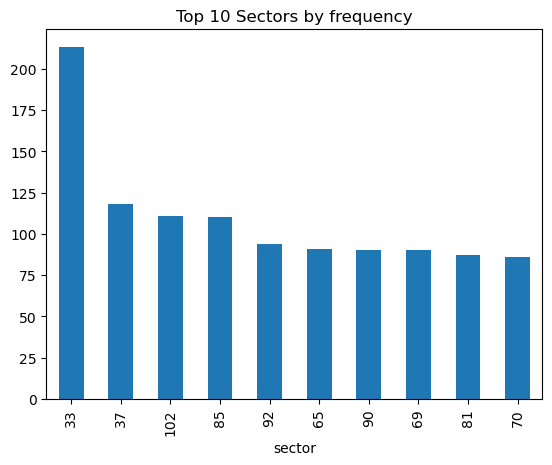

In [27]:
df['sector'].value_counts().head(10).plot(kind='bar', title='Top 10 Sectors by frequency')

<Axes: xlabel='price_cr', ylabel='Count'>

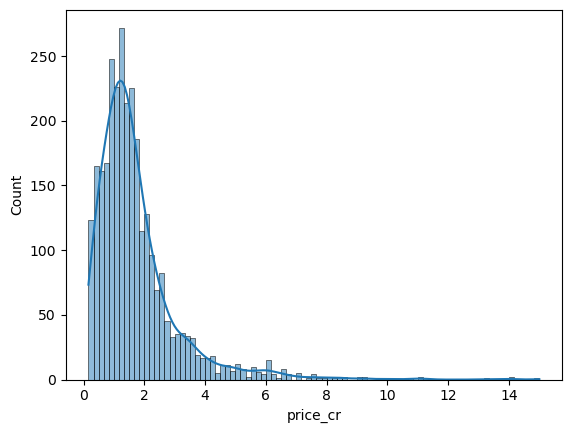

In [28]:
sns.histplot(df['price_cr'], kde=True)

In [29]:
print("Price Skewness: ", df['price_cr'].skew())

Price Skewness:  2.9569338128348117


In [30]:
print("Price Kurtosis: ", df['price_cr'].kurt())

Price Kurtosis:  14.60009621918686


In [31]:
quantiles = df['price_cr'].quantile([0.01, 0.1, 0.25, 0.50, 0.75, 0.90, 0.99])
quantiles

0.01    0.24
0.10    0.50
0.25    0.90
0.50    1.40
0.75    2.09
0.90    3.25
0.99    7.00
Name: price_cr, dtype: float64

In [32]:
#50% flats are below 1.4 Crore Rupees

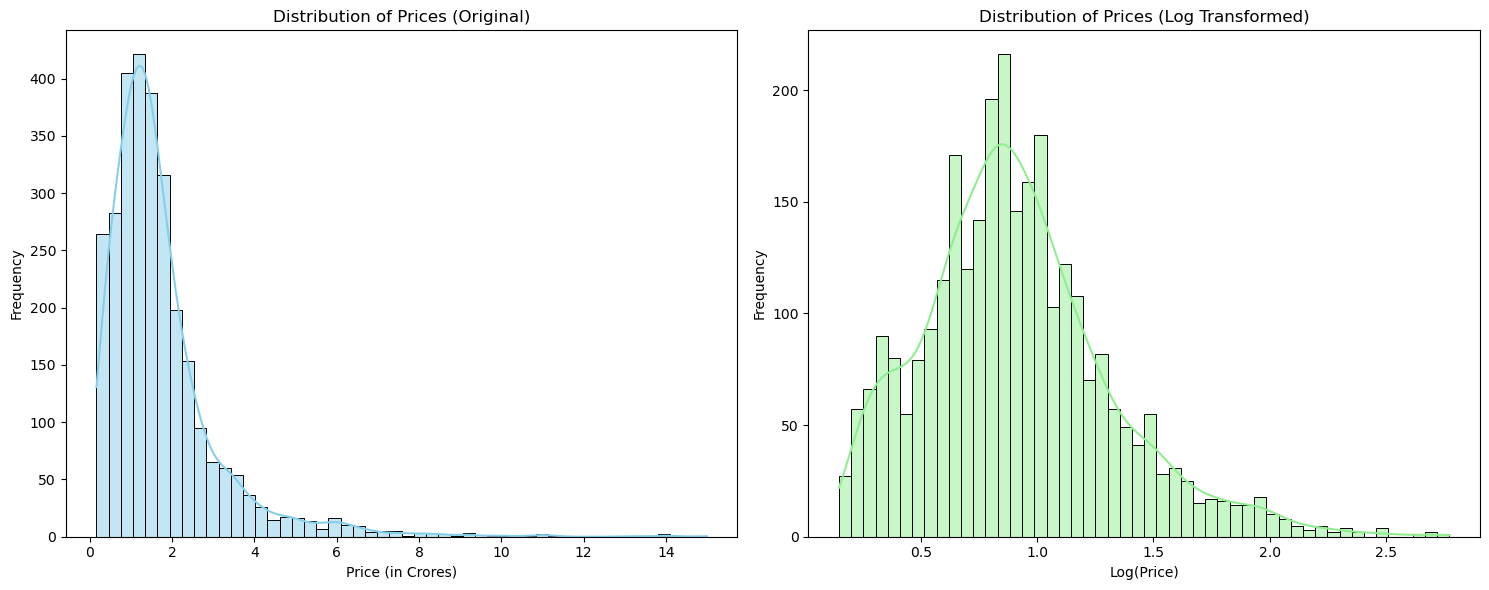

In [33]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_cr'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_cr']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: xlabel='price_cr'>

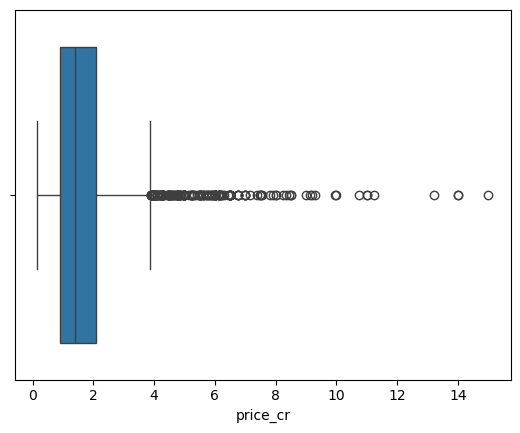

In [34]:
sns.boxplot(x=df['price_cr'])

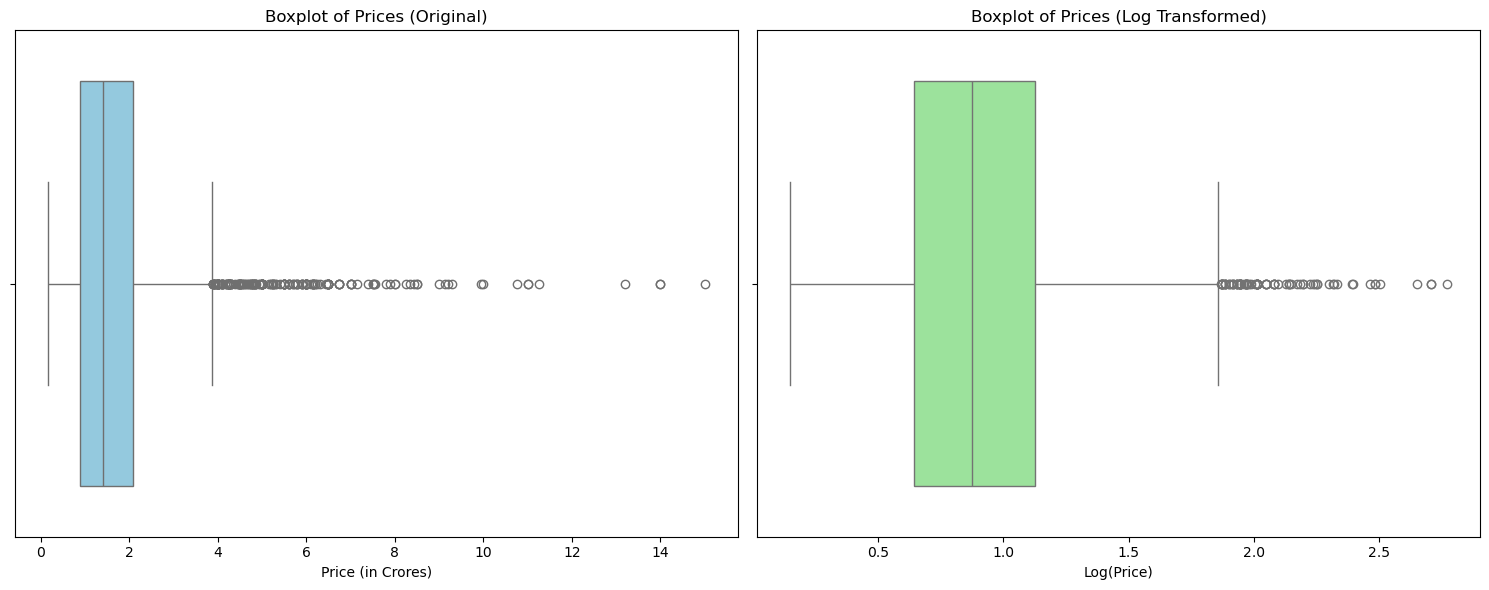

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price_cr'], color='skyblue')
plt.title('Boxplot of Prices (Original)')
plt.xlabel('Price (in Crores)')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price_cr']), color='lightgreen')
plt.title('Boxplot of Prices (Log Transformed)')
plt.xlabel('Log(Price)')

plt.tight_layout()
plt.show()

<Axes: title={'center': '#Flats for each bhk type'}, ylabel='bhk'>

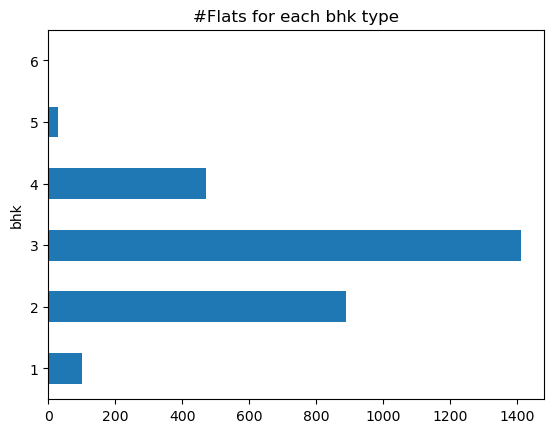

In [36]:
df['bhk'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bhk type')

<Axes: title={'center': '#Flats for each bathroom type'}, ylabel='bathroom'>

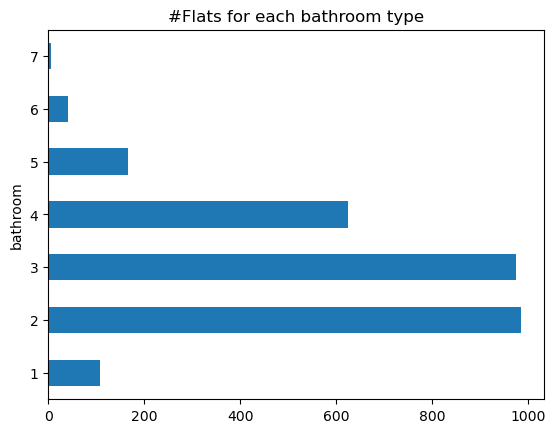

In [37]:
df['bathroom'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bathroom type')

<Axes: title={'center': '#bathroom proportion'}, ylabel='proportion'>

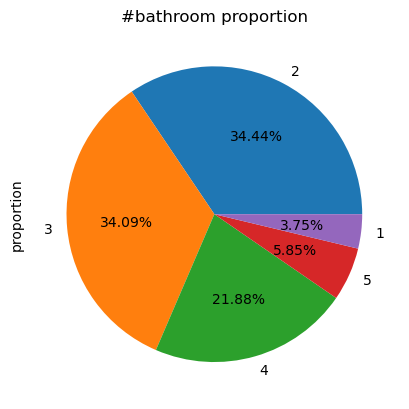

In [38]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%',
                                                        title='#bathroom proportion')

<Axes: title={'center': '#Flats for each balcony type'}, ylabel='balcony'>

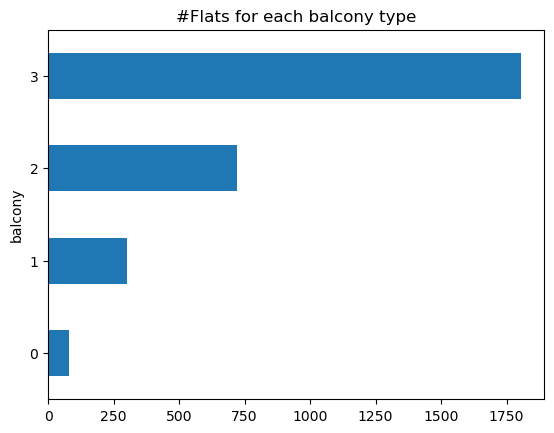

In [39]:
df['balcony'].value_counts().sort_index().plot(kind='barh', title='#Flats for each balcony type')

<Axes: xlabel='floor_rise'>

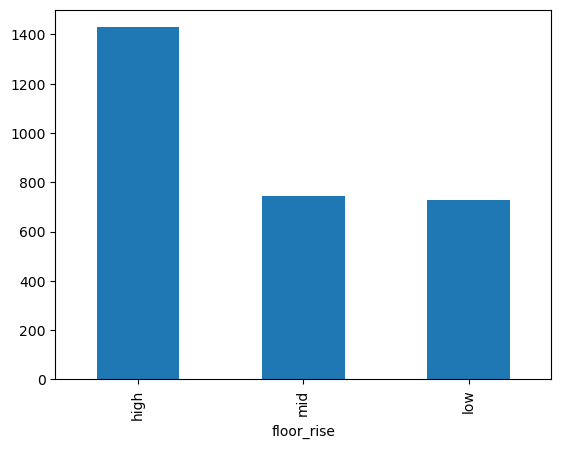

In [40]:
df['floor_rise'].value_counts().plot(kind='bar')

<Axes: ylabel='age'>

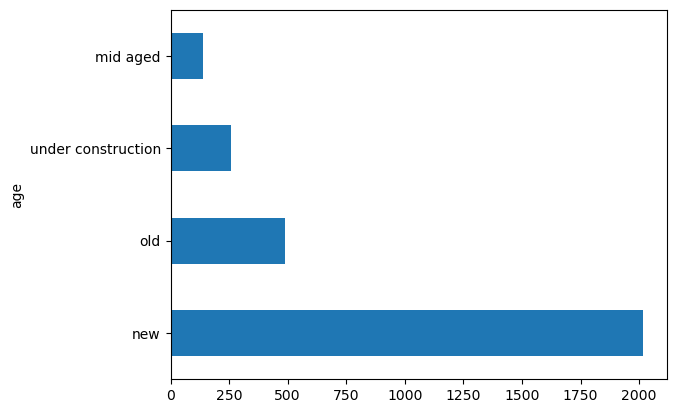

In [41]:
df['age'].value_counts().plot(kind='barh')

<Axes: ylabel='area_sqm'>

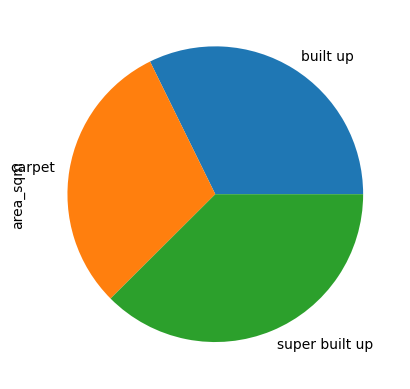

In [42]:
df.groupby('area_type')['area_sqm'].mean().plot(kind='pie')

In [44]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Pandas Profiling Report', explorative=True)

profile.to_file('10_df_profiling.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 237.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [45]:
profile = ProfileReport(
    df,
    title="10_df_profiling",
    dataset={
        "description": "99 Acres Dataset Description",
        "author": "Gaurav Singh",
    },
    variables={
        "descriptions": {
            "col1": "Description of all columns",
        }
    },
    explorative=True,   # deeper analysis
    minimal=False,      # set True for large datasets
)
profile.to_file("10_df_profiling.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 504.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]